In [1]:
import os
import pandas as pd
import plotnine as pln

In [2]:
#dir_path = '../experiments/fineTune/esmc_300m/DENV2_NS5_score_Suphatrakul2023/'
dir_path = '../experiments/fineTune/esm2_t33_650M_UR50D/viral/pool_split/HIV1_BF520_ENV_Haddox/version_98/'

def read_CSVLogger(dir_path):
    df = pd.read_csv(f"{dir_path}/metrics.csv")
    train_df = df[df["train_loss"].notna()].copy().drop(columns=["val_loss", "val_r2"])
    val_df = df[df["val_loss"].notna()].copy().drop(columns=["train_loss", "train_r2"])
    res = pd.merge(train_df, val_df, on=["epoch", "step"])
    res.rename(columns={"epoch": "Epoch"}, inplace=True)
    res['Epoch'] = res['Epoch'].astype(int) + 1
    # Filter rows where the difference between train_r2 and val_r2 is smaller than 0.1
    diff = res[abs(res['train_r2'] - res['val_r2']) < 0.1]
    best_epoch = diff['val_r2'].idxmax()
    res['best_epoch'] = best_epoch + 1
    return res

res = read_CSVLogger(dir_path)
res

,Epoch,step,train_loss,train_r2,val_loss,val_r2,best_epoch
0,1,313,1.095639,-0.095846,1.010531,-0.008390,19
1,2,627,1.027608,-0.027159,1.066549,-0.064288,19
2,3,941,1.019826,-0.019421,1.010189,-0.008047,19
3,4,1255,1.017141,-0.017263,1.005600,-0.003468,19
4,5,1569,1.009826,-0.009483,1.004313,-0.002185,19
5,6,1883,1.008427,-0.008555,1.026513,-0.024337,19
6,7,2197,1.006848,-0.006733,1.009207,-0.007068,19
7,8,2511,1.003376,-0.002687,1.143002,-0.140580,19
8,9,2825,0.961971,0.038360,0.912159,0.089774,19
9,10,3139,0.897041,0.102965,0.908080,0.093845,19


In [3]:
dts_order = [
    'BF520_env_Bloom2018',
    'BG505_env_Bloom2018',
    'PA_FLU_Sun2015',
    'HG_FLU_Bloom2016',

    'CVB3_capsid_MFE_Mattenberger2021',
    'CVB3_capsid_MFElog2_Mattenberger2021',

    'DENV2_NS5_score_Suphatrakul2023',

    'H1N1_NEP_enri_Teo2024',
    'H1N1_NEP_RF_Teo2024',

    'H3N2_HA_effect_Welsh2024',
    'H3N2_NA_fitness_Lei2023',

    'HIV1_Rev_SelCoeff_Fernandes2016',
    'HIV1_Tat_SelCoeff_Fernandes2016',
    
    'Zika_env_effect_Sourisseau2019',
    'Zika_env_log2effect_Sourisseau2019',

    'H1N1_PA_ddg_Wu2015',
    'H1N1_M1_RF_Wu2016',
    'H1N1_M1_maxRF_Wu2016',
    'H1N1_M2_RF_Wu2016',
    'H1N1_M2_maxRF_Wu2016',

    'OmiXBB15_spike_ACE2bind_Dadonaite2024',
    'OmiXBB15_spike_entry_Dadonaite2024',
    'OmiXBB15_spike_escape_Dadonaite2024',
    'Delta_spike_latent_Dadonaite2023',
    'Delta_spike_observed_Dadonaite2023',
 ]

In [7]:
res_dir = f'../experiments/fineTune/esm2_t33_650M_UR50D/viral/pool_split'

res = pd.DataFrame()
for dataset in os.listdir(f'{res_dir}/'):
    if 'Alvarez' not in dataset and 'IAV' not in dataset:
        dataset_dir = f'{res_dir}/{dataset}/version_98'
        df = read_CSVLogger(dataset_dir)
        df['Dataset'] = dataset
        df['Lab'] = dataset.split('_')[-1]
        res = pd.concat([res, df], ignore_index=True).reset_index(drop=True)

dts_order = list(res['Lab'].sort_values().unique())
res['Lab'] = pd.Categorical(res['Lab'], categories=dts_order, ordered=True)
#res['Model'] = 'esm2_650m'
res

,Epoch,step,train_loss,train_r2,val_loss,val_r2,best_epoch,Dataset,Lab
0,1,243,1.142998,-0.142866,1.000590,-0.000099,6,SARS2_DELTA_SPIKE_Dadonaite,Dadonaite
1,2,487,1.020664,-0.020546,1.022259,-0.021758,6,SARS2_DELTA_SPIKE_Dadonaite,Dadonaite
2,3,731,1.014671,-0.014552,1.009324,-0.008829,6,SARS2_DELTA_SPIKE_Dadonaite,Dadonaite
3,4,975,1.016248,-0.016126,1.021294,-0.020794,6,SARS2_DELTA_SPIKE_Dadonaite,Dadonaite
4,5,1219,1.010710,-0.010593,1.003453,-0.002961,6,SARS2_DELTA_SPIKE_Dadonaite,Dadonaite
...,...,...,...,...,...,...,...,...,...
440,34,2923,0.655664,0.346641,0.875541,0.143500,28,RmYN02_RBD_Starr,Starr
441,35,3009,0.624901,0.375513,0.808362,0.209218,28,RmYN02_RBD_Starr,Starr
442,36,3095,0.565666,0.415523,0.802050,0.215393,28,RmYN02_RBD_Starr,Starr
443,37,3181,0.621435,0.379951,0.864539,0.154263,28,RmYN02_RBD_Starr,Starr


In [26]:
# plot = (pln.ggplot(res)
#         + pln.geom_line(pln.aes(x='Epoch', y='train_loss', color="'Train Loss'"))
#         + pln.geom_line(pln.aes(x='Epoch', y='val_loss', color="'Validation Loss'"))
#         + pln.geom_vline(pln.aes(xintercept='best_epoch'), color='black', linetype='dashed')
#         + pln.xlab('Epoch')
#         + pln.ylab('Loss')
#         + pln.facet_wrap('Dataset', scales="free_y", ncol=3)
#         + pln.labs(color="Metric")
#         + pln.theme(figure_size=(9, 12)) 
#         )
# plot

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


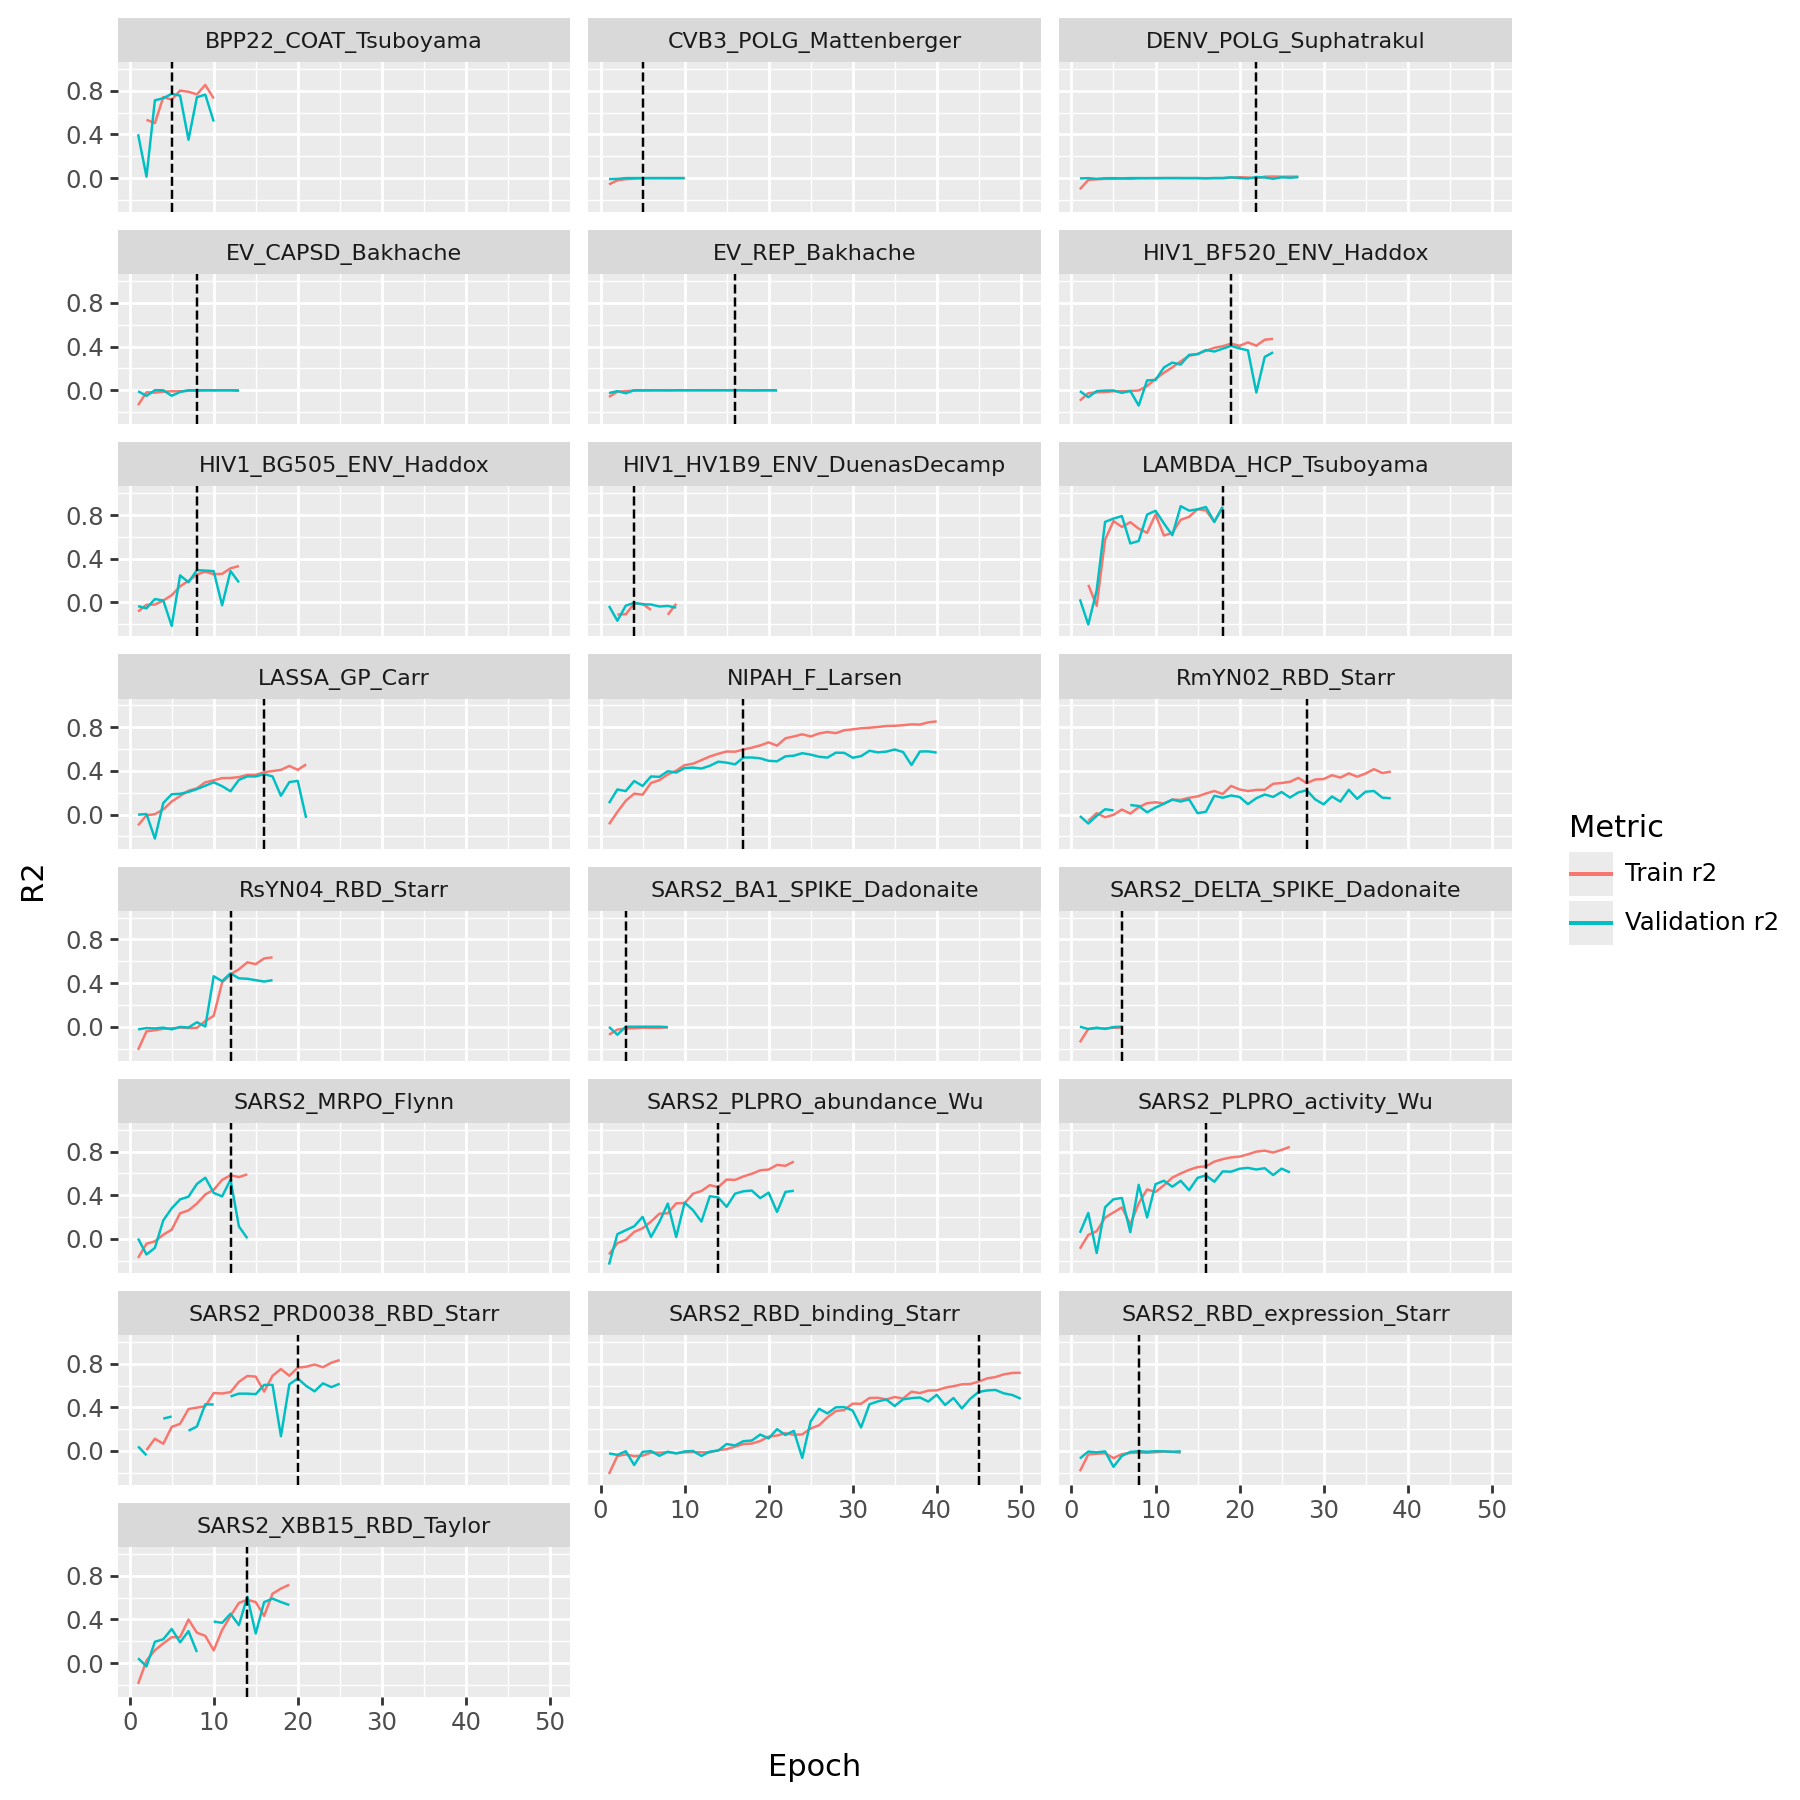

In [8]:
plot = (pln.ggplot(res)
        + pln.geom_line(pln.aes(x='Epoch', y='train_r2', color="'Train r2'"))
        + pln.geom_line(pln.aes(x='Epoch', y='val_r2', color="'Validation r2'"))
        + pln.geom_vline(pln.aes(xintercept='best_epoch'), color='black', linetype='dashed')
        + pln.xlab('Epoch')
        + pln.ylab('R2')        
        + pln.facet_wrap('Dataset',  ncol=3)
        + pln.labs(color="Metric")
        + pln.ylim(-0.25, 1)
        + pln.theme(figure_size=(9, 9), strip_text=pln.element_text(size=8)) 
        )
plot#.save(filename='../experiments/finetune_r2.png', dpi=600)

# vicam

In [9]:
res_dir = f'../experiments/fineTune/esm2_viral_650M/viral/pool_split'

res2 = pd.DataFrame()
for dataset in os.listdir(f'{res_dir}/'):
    dataset_dir = f'{res_dir}/{dataset}/version_98'
    df = read_CSVLogger(dataset_dir)
    df['Dataset'] = dataset
    df['Lab'] = dataset.split('_')[-1]
    res2 = pd.concat([res2, df], ignore_index=True).reset_index(drop=True)


dts_order = list(res2['Lab'].sort_values().unique())

res2['Lab'] = pd.Categorical(res2['Lab'], categories=dts_order, ordered=True)
res2['Model'] = 'vicam_300m'
res2

,Epoch,step,train_loss,train_r2,val_loss,val_r2,best_epoch,Dataset,Lab,Model
0,1,94,1.281038,-0.280650,1.087102,-0.088893,9,SARS2_RBD_binding_Starr,Starr,vicam_300m
1,2,189,0.999493,0.000702,0.935289,0.063171,9,SARS2_RBD_binding_Starr,Starr,vicam_300m
2,3,284,0.916978,0.083304,0.702757,0.296086,9,SARS2_RBD_binding_Starr,Starr,vicam_300m
3,4,379,0.667038,0.333076,0.601431,0.397578,9,SARS2_RBD_binding_Starr,Starr,vicam_300m
4,5,474,0.488071,0.511122,0.464142,0.535094,9,SARS2_RBD_binding_Starr,Starr,vicam_300m
...,...,...,...,...,...,...,...,...,...,...
339,32,8031,0.298045,0.701718,0.484600,0.515400,19,NIPAH_F_Larsen,Larsen,vicam_300m
340,33,8282,0.277608,0.722344,0.625938,0.374062,19,NIPAH_F_Larsen,Larsen,vicam_300m
341,34,8533,0.277657,0.722597,0.450358,0.549642,19,NIPAH_F_Larsen,Larsen,vicam_300m
342,35,8784,0.293907,0.705902,0.452316,0.547684,19,NIPAH_F_Larsen,Larsen,vicam_300m


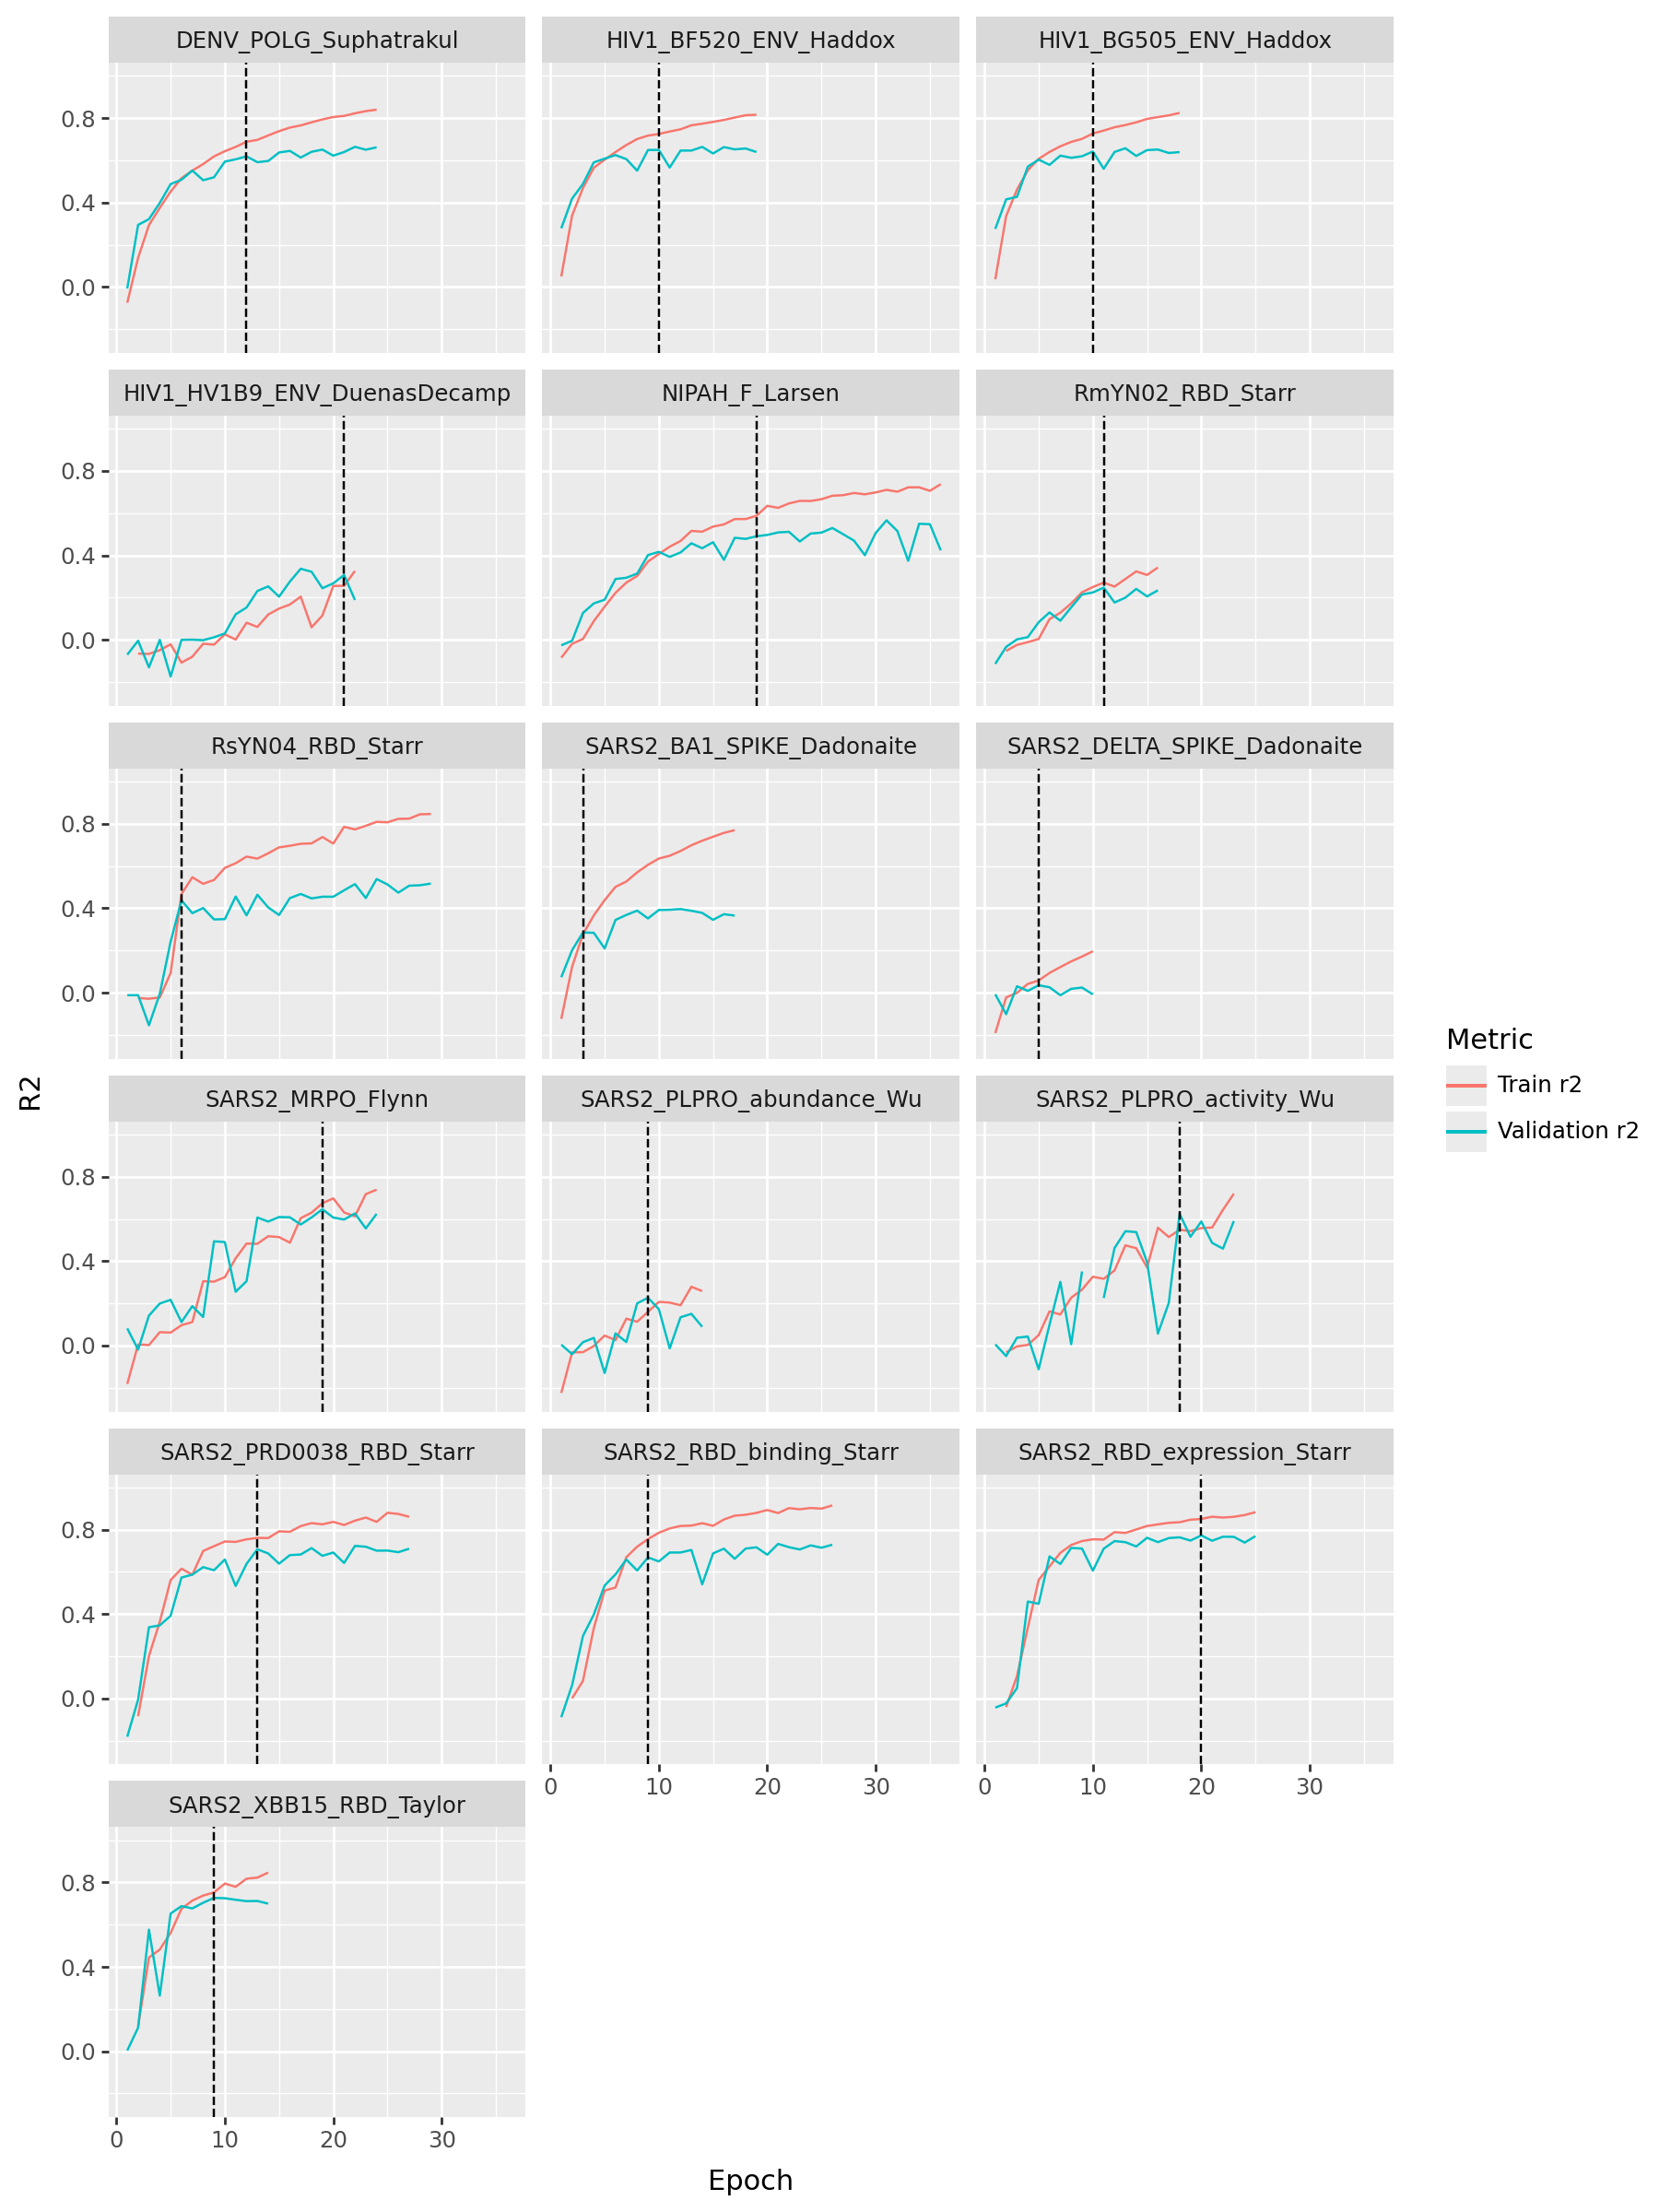

In [10]:
plot = (pln.ggplot(res2)
        + pln.geom_line(pln.aes(x='Epoch', y='train_r2', color="'Train r2'"))
        + pln.geom_line(pln.aes(x='Epoch', y='val_r2', color="'Validation r2'"))
        + pln.geom_vline(pln.aes(xintercept='best_epoch'), color='black', linetype='dashed')
        + pln.xlab('Epoch')
        + pln.ylab('R2')
        + pln.facet_wrap('Dataset',  ncol=3)
        + pln.labs(color="Metric")
        + pln.ylim(-0.25, 1)
        + pln.theme(figure_size=(9, 12)) 
        )
plot#.save(filename='../experiments/finetune_r2.png', dpi=600)

# Fitness finetune results 

In [9]:
import os
import pandas as pd
import plotnine as pln

In [10]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/nonviral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/nonviral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

In [2]:
# Deleted: Dodonaite2024, wu2016

dts = [
    'BF520_env_Bloom2018', 'H3N2_HA_effect_Welsh2024',
    'BG505_env_Bloom2018', 'H3N2_NA_fitness_Lei2023', 
    'HG_FLU_Bloom2016', 'PA_FLU_Sun2015',
    'H1N1_NEP_enri_Teo2024', 'HIV1_Rev_SelCoeff_Fernandes2016', 'DENV2_NS5_score_Suphatrakul2023', 'H1N1_NEP_RF_Teo2024',
    'HIV1_Tat_SelCoeff_Fernandes2016', 'Zika_env_effect_Sourisseau2019',
    'Zika_env_log2effect_Sourisseau2019',
]


# dys = [
#     'BF520_env_Bloom2018', 'H1N1_M1_RF_Wu2016', 'H3N2_HA_effect_Welsh2024', 'OmiXBB15_spike_entry_Dadonaite2024',
#     'BG505_env_Bloom2018', 'H1N1_M2_maxRF_Wu2016', 'H3N2_NA_fitness_Lei2023', 'OmiXBB15_spike_escape_Dadonaite2024',
#     'CVB3_capsid_MFElog2_Mattenberger2021', 'H1N1_M2_RF_Wu2016', 'HG_FLU_Bloom2016', 'PA_FLU_Sun2015', 'CVB3_capsid_MFE_Mattenberger2021', 
#     'H1N1_NEP_enri_Teo2024', 'HIV1_Rev_SelCoeff_Fernandes2016', 'DENV2_NS5_score_Suphatrakul2023', 'H1N1_NEP_RF_Teo2024',
#     'HIV1_Tat_SelCoeff_Fernandes2016', 'Zika_env_effect_Sourisseau2019',
#     'H1N1_PA_ddg_Wu2015', 'H1N1_M1_maxRF_Wu2016', 'OmiXBB15_spike_ACE2bind_Dadonaite2024', 'Zika_env_log2effect_Sourisseau2019',
#     'Delta_spike_observed_Dadonaite2023', 'Delta_spike_latent_Dadonaite2023',
# ]

In [ ]:
# def read_CSVLogger(dir_path):
#     df = pd.read_csv(f"{dir_path}/metrics.csv")
#     train_df = df[df["train_loss"].notna()].copy().drop(columns=["val_loss", "val_r2"])
#     val_df = df[df["val_loss"].notna()].copy().drop(columns=["train_loss", "train_r2"])
#     res = pd.merge(train_df, val_df, on=["epoch", "step"])
#     res.rename(columns={"epoch": "Epoch"}, inplace=True)
#     res['Epoch'] = res['Epoch'].astype(int) + 1
#     # Filter rows where the difference between train_r2 and val_r2 is smaller than 0.1
#     diff = res[abs(res['train_r2'] - res['val_r2']) < 0.1]
#     best_epoch = diff['val_r2'].idxmax()
#     res['best_epoch'] = best_epoch + 1
#     res = res.iloc[[best_epoch], :]
#     return res


In [ ]:
# res_dir = f'../experiments/fineTune/esmc_300m_v01'
# res = pd.DataFrame()
# for dataset in os.listdir(f'{res_dir}/'):
#     dataset_dir = f'{res_dir}/{dataset}'
#     df = read_CSVLogger(dataset_dir)
#     df['Dataset'] = dataset
#     res = pd.concat([res, df], ignore_index=True).reset_index(drop=True)
# res['Model'] = 'esmc_300m'


# res_dir = f'../experiments/fineTune/vicam_300m_v01'
# res2 = pd.DataFrame()
# for dataset in os.listdir(f'{res_dir}/'):
#     dataset_dir = f'{res_dir}/{dataset}'
#     df = read_CSVLogger(dataset_dir)
#     df['Dataset'] = dataset
#     res2 = pd.concat([res2, df], ignore_index=True).reset_index(drop=True)
# res2['Model'] = 'vicam_300m'


# res_full = pd.concat([res, res2], ignore_index=True)
# res_full = res_full.query('Dataset in @dts')
# res_full

In [ ]:
# df = pd.read_csv("../experiments/fineTune/esm2_t33_650M_UR50D/viral/site_split/CVB3_3C_Alvarez/version_374/metrics.csv")
                    
# train_df = df[df["train_loss"].notna()].copy().drop(columns=["val_loss", "val_r2"])
# val_df = df[df["val_loss"].notna()].copy().drop(columns=["train_loss", "train_r2"])
# res = pd.merge(train_df, val_df, on=["epoch", "step"])
# res.rename(columns={"epoch": "Epoch"}, inplace=True)
# res['Epoch'] = res['Epoch'].astype(int) + 1

# # This will pick the epoch that maximizes validation R² while minimizing the train–validation gap
# diff = (res['train_r2'] - res['val_r2']).abs()
# best_epoch = (res['val_r2'] / (diff + 1e-6)).idxmax()  # high val_r2 and low gap
# res['best_epoch'] = best_epoch + 1
# res

In [37]:
# version 2. 
def read_CSVLogger(dir_path):
    full_res = pd.DataFrame()
    for method in ['pool_split', 'site_split']:
        dataset_dir = f'{dir_path}/{method}'
        for dataset in os.listdir(dataset_dir):
            if 'CVB3_POLG' not in dataset: # just temporary
                for seed in ['98', '374', '1234']:
                    df = pd.read_csv(f"{dataset_dir}/{dataset}/version_{seed}/metrics.csv")
                    
                    train_df = df[df["train_loss"].notna()].copy().drop(columns=["val_loss", "val_r2"])
                    val_df = df[df["val_loss"].notna()].copy().drop(columns=["train_loss", "train_r2"])
                    res = pd.merge(train_df, val_df, on=["epoch", "step"])
                    res.rename(columns={"epoch": "Epoch"}, inplace=True)
                    res['Epoch'] = res['Epoch'].astype(int) + 1
                    res['Dataset'] = dataset
                    res['split_strategy'] = method
                    res['Seed'] = seed

                    # This will pick the epoch that maximizes validation R² while minimizing the train–validation gap
                    diff = (res['train_r2'] - res['val_r2']).abs()
                    best_epoch = (res['val_r2'] / (diff + 1e-6)).idxmax()  # high val_r2 and low gap
                    res['best_epoch'] = best_epoch + 1
                    res = res.iloc[[best_epoch], :]
            
                    full_res = pd.concat([full_res, res])

    return full_res

In [38]:
res_viral = pd.DataFrame()
for model in ['esm2_viral_650M', 'esm2_t33_650M_UR50D']:
    res_dir = f'../experiments/fineTune/{model}/viral'
    res = read_CSVLogger(res_dir)
    res['Model'] = model
    res_viral = pd.concat([res_viral , res], ignore_index=True)

res_viral['Model'] = pd.Categorical(res_viral['Model'], categories=['esm2_viral_650M', 'esm2_t33_650M_UR50D'], ordered=True)
cols = ['train_loss','train_r2','val_loss','val_r2']
res_viral = res_viral.groupby(['Model', 'Dataset', 'split_strategy'], as_index=False, observed=True)[cols].mean()
res_viral['Source'] = 'Viral' 
res_viral["protein_length"] = res_viral['Dataset'].map(prot_lengths)
res_viral

,Model,Dataset,split_strategy,train_loss,train_r2,val_loss,val_r2,Source,protein_length
0,esm2_viral_650M,BPP22_COAT_Tsuboyama,pool_split,0.196039,0.802461,0.193312,0.805520,Viral,40
1,esm2_viral_650M,BPP22_COAT_Tsuboyama,site_split,0.386189,0.614164,0.613497,0.390950,Viral,40
2,esm2_viral_650M,CVB3_2A_Alvarez,pool_split,0.310961,0.689259,0.336462,0.662497,Viral,150
3,esm2_viral_650M,CVB3_2A_Alvarez,site_split,0.290047,0.709935,0.835323,0.157462,Viral,150
4,esm2_viral_650M,CVB3_2B_Alvarez,pool_split,0.468121,0.531865,0.458218,0.541585,Viral,99
...,...,...,...,...,...,...,...,...,...
155,esm2_t33_650M_UR50D,SARS2_RBD_binding_Starr,site_split,1.024284,-0.023938,1.005370,0.000082,Viral,1273
156,esm2_t33_650M_UR50D,SARS2_RBD_expression_Starr,pool_split,1.023539,-0.023344,1.006054,-0.000657,Viral,1273
157,esm2_t33_650M_UR50D,SARS2_RBD_expression_Starr,site_split,1.088441,-0.087817,0.998969,-0.000327,Viral,1273
158,esm2_t33_650M_UR50D,SARS2_XBB15_RBD_Taylor,pool_split,0.561676,0.438911,0.550857,0.450727,Viral,201


In [39]:
res_viral['Dataset'] = res_viral['Dataset'].apply(lambda x: x.split('_')[0])
cols = ['train_loss', 'train_r2', 'val_loss', 'val_r2', "protein_length"]
res_viral = res_viral.groupby(['Model', 'Source', 'Dataset', 'split_strategy'], as_index=False, observed=True)[cols].mean()
res_viral

,Model,Source,Dataset,split_strategy,train_loss,train_r2,val_loss,val_r2,protein_length
0,esm2_viral_650M,Viral,BPP22,pool_split,0.196039,0.802461,0.193312,0.805520,40.000000
1,esm2_viral_650M,Viral,BPP22,site_split,0.386189,0.614164,0.613497,0.390950,40.000000
2,esm2_viral_650M,Viral,CVB3,pool_split,0.468121,0.531988,0.477585,0.522314,205.888889
3,esm2_viral_650M,Viral,CVB3,site_split,0.628518,0.371560,0.755585,0.245519,205.888889
4,esm2_viral_650M,Viral,DENV,pool_split,0.473004,0.526904,0.479476,0.519773,900.000000
5,esm2_viral_650M,Viral,DENV,site_split,0.791451,0.208674,0.765383,0.235561,900.000000
6,esm2_viral_650M,Viral,EV,pool_split,0.967577,0.032628,0.961517,0.038286,1096.500000
7,esm2_viral_650M,Viral,EV,site_split,0.927549,0.072401,0.965160,0.032633,1096.500000
8,esm2_viral_650M,Viral,HIV1,pool_split,0.601741,0.388646,0.570866,0.414255,855.000000
9,esm2_viral_650M,Viral,HIV1,site_split,1.099824,-0.096913,0.749770,0.198759,855.000000


In [40]:
res_nonviral = pd.DataFrame()
for model in ['esm2_t33_650M_UR50D']:
    res_dir = f'../experiments/fineTune/{model}/nonviral'
    res = read_CSVLogger(res_dir)
    res['Model'] = model
    res_nonviral = pd.concat([res_nonviral , res], ignore_index=True)

res_nonviral['Model'] = pd.Categorical(res_nonviral['Model'], categories=['esm2_viral_650M', 'esm2_t33_650M_UR50D'], ordered=True)
cols = ['train_loss','train_r2','val_loss','val_r2']
res_nonviral = res_nonviral.groupby(['Model', 'Dataset', 'split_strategy'], as_index=False, observed=True)[cols].mean()
res_nonviral['Source'] = 'Non-Viral' 
res_nonviral["protein_length"] = res_nonviral['Dataset'].map(prot_lengths)
res_nonviral = res_nonviral[res_viral.columns]

In [41]:
res_full = pd.concat([res_viral, res_nonviral])
res_full

,Model,Source,Dataset,split_strategy,train_loss,train_r2,val_loss,val_r2,protein_length
0,esm2_viral_650M,Viral,BPP22,pool_split,0.196039,0.802461,0.193312,0.805520,40.000000
1,esm2_viral_650M,Viral,BPP22,site_split,0.386189,0.614164,0.613497,0.390950,40.000000
2,esm2_viral_650M,Viral,CVB3,pool_split,0.468121,0.531988,0.477585,0.522314,205.888889
3,esm2_viral_650M,Viral,CVB3,site_split,0.628518,0.371560,0.755585,0.245519,205.888889
4,esm2_viral_650M,Viral,DENV,pool_split,0.473004,0.526904,0.479476,0.519773,900.000000
...,...,...,...,...,...,...,...,...,...
61,esm2_t33_650M_UR50D,Non-Viral,UBC9_HUMAN_Roth2017,site_split,0.805223,0.194248,0.856029,0.144218,159.000000
62,esm2_t33_650M_UR50D,Non-Viral,UBE4B_MOUSE_Klevit2013_singles,pool_split,2.219829,-1.229523,0.945571,-0.010066,1173.000000
63,esm2_t33_650M_UR50D,Non-Viral,UBE4B_MOUSE_Klevit2013_singles,site_split,1.051897,-0.051324,1.044824,-0.000251,1173.000000
64,esm2_t33_650M_UR50D,Non-Viral,YAP1_HUMAN_Fields2012_singles,pool_split,1.820192,-0.815923,0.794285,0.191104,504.000000


In [42]:
res_full['Model'] = res_full['Model'].replace({
    "esm2_viral_650M": "ESM-2 Viral",
    "esm2_t33_650M_UR50D": "ESM-2 Base",
})

/tmp/ipykernel_3922768/4123847377.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [43]:
res_full['split_strategy'] = res_full['split_strategy'].replace({
    "pool_split": "Pool Split",
    "site_split": "Site Split",
})

In [44]:
# res_full["protein_length"] = res_full['Dataset'].map(prot_lengths)
# res_full

In [45]:
res_full.query('val_r2 < 0.1')#['Dataset'].unique()

,Model,Source,Dataset,split_strategy,train_loss,train_r2,val_loss,val_r2,protein_length
6,ESM-2 Viral,Viral,EV,Pool Split,0.967577,0.032628,0.961517,0.038286,1096.500000
7,ESM-2 Viral,Viral,EV,Site Split,0.927549,0.072401,0.965160,0.032633,1096.500000
21,ESM-2 Viral,Viral,RsYN04,Site Split,1.039152,-0.036947,1.034748,-0.005842,517.000000
28,ESM-2 Base,Viral,DENV,Pool Split,0.950873,0.049301,0.947874,0.050553,900.000000
29,ESM-2 Base,Viral,DENV,Site Split,1.007311,-0.007411,0.999229,0.002015,900.000000
30,ESM-2 Base,Viral,EV,Pool Split,1.005965,-0.006104,0.999829,-0.000030,1096.500000
31,ESM-2 Base,Viral,EV,Site Split,1.010850,-0.010802,0.997829,-0.000193,1096.500000
33,ESM-2 Base,Viral,HIV1,Site Split,1.117718,-0.123839,0.884400,0.065816,855.000000
34,ESM-2 Base,Viral,IAV,Pool Split,1.054537,-0.052113,1.007561,-0.001283,594.400000
35,ESM-2 Base,Viral,IAV,Site Split,1.072139,-0.072944,0.997253,0.013812,594.400000


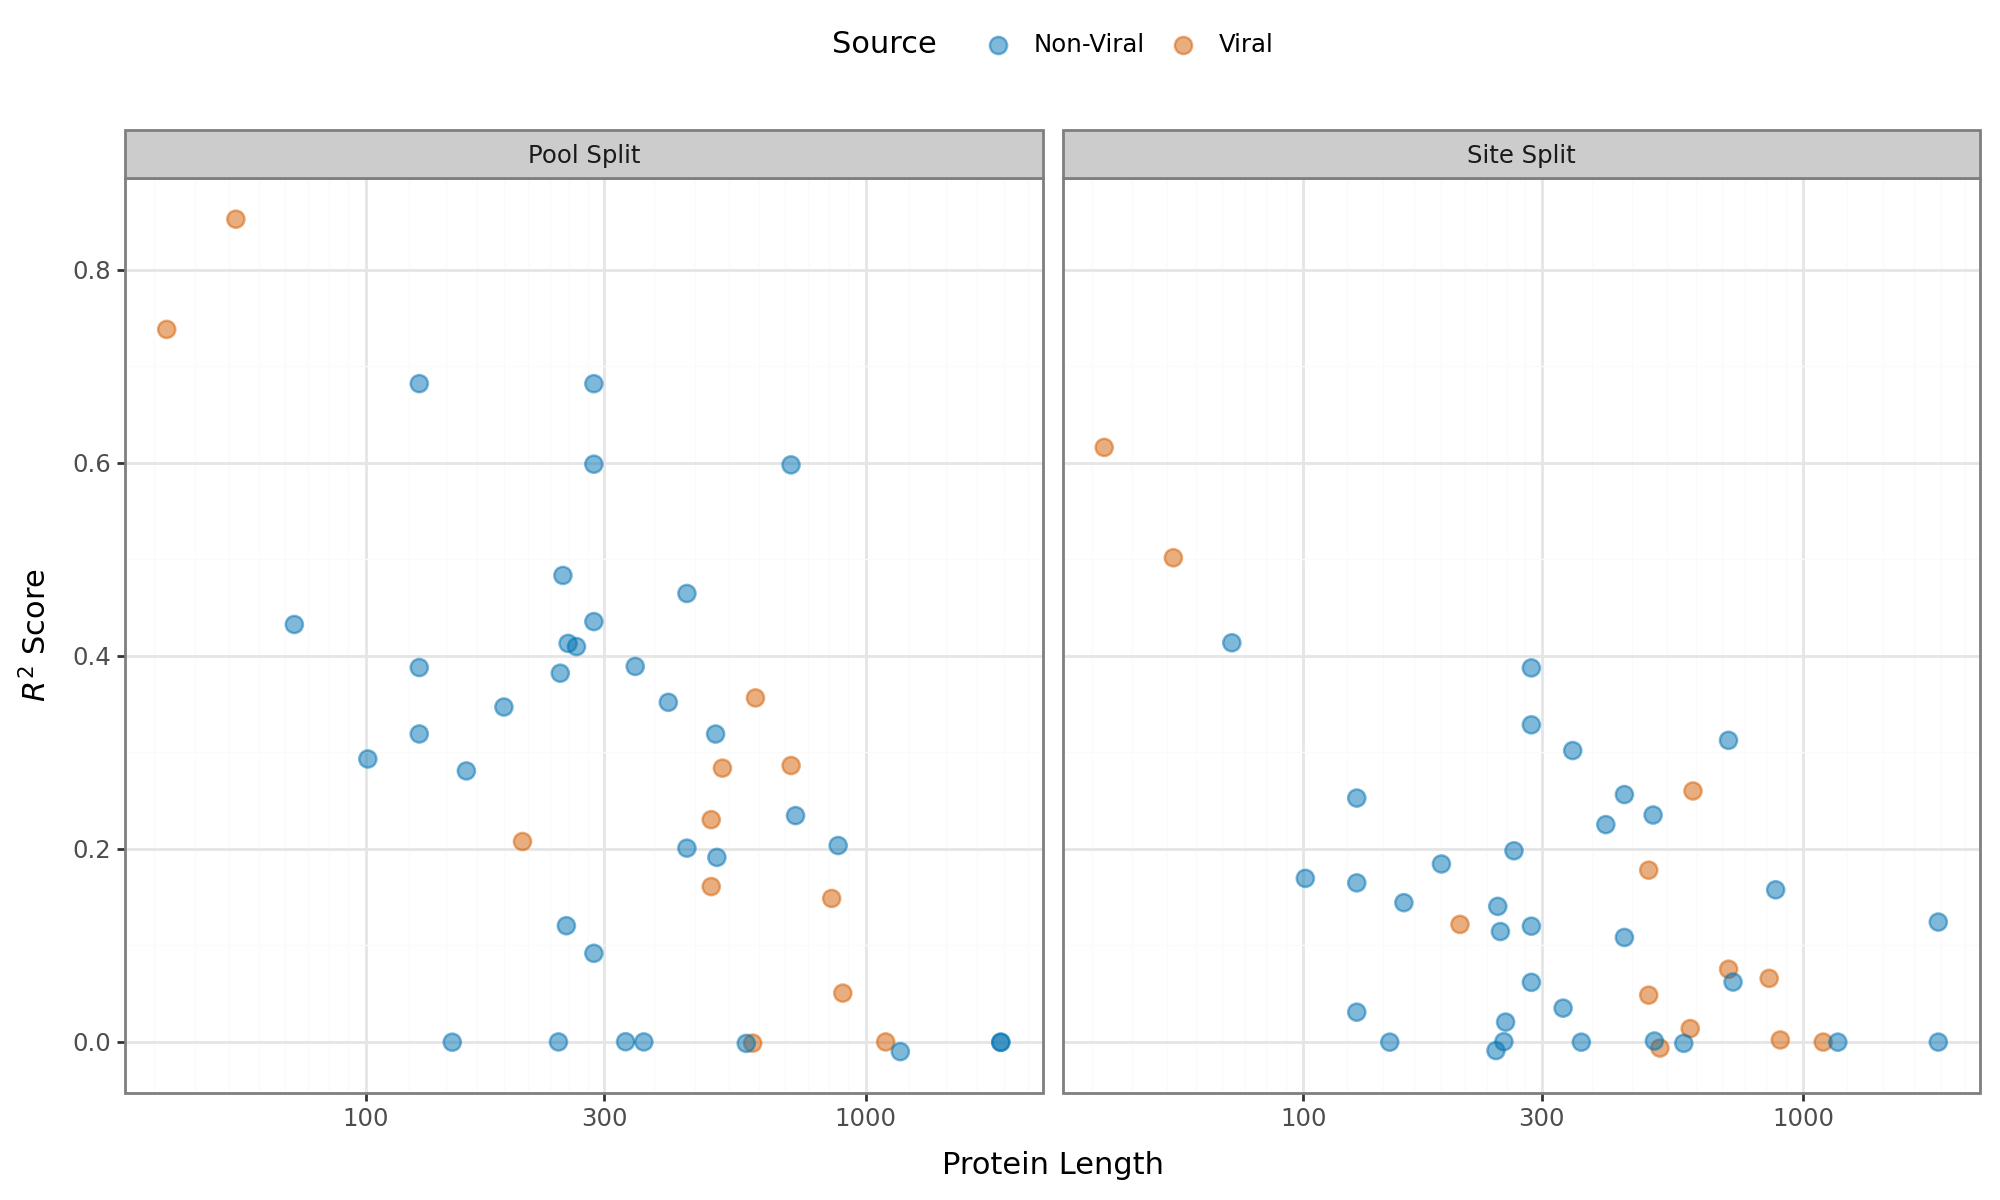

In [47]:
plot = (
    pln.ggplot(res_full.query('Model == "ESM-2 Base"'), pln.aes(x='protein_length', y='val_r2'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"Viral": "#D55E00", "Non-Viral": "#0072B2"})
    + pln.facet_wrap('split_strategy')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',)
    #+ pln.ylim(-0.2, 0.8)

)
plot#.save(filename='../experiments/protein_length_vs_lassocv_r2_full.png', dpi=600)

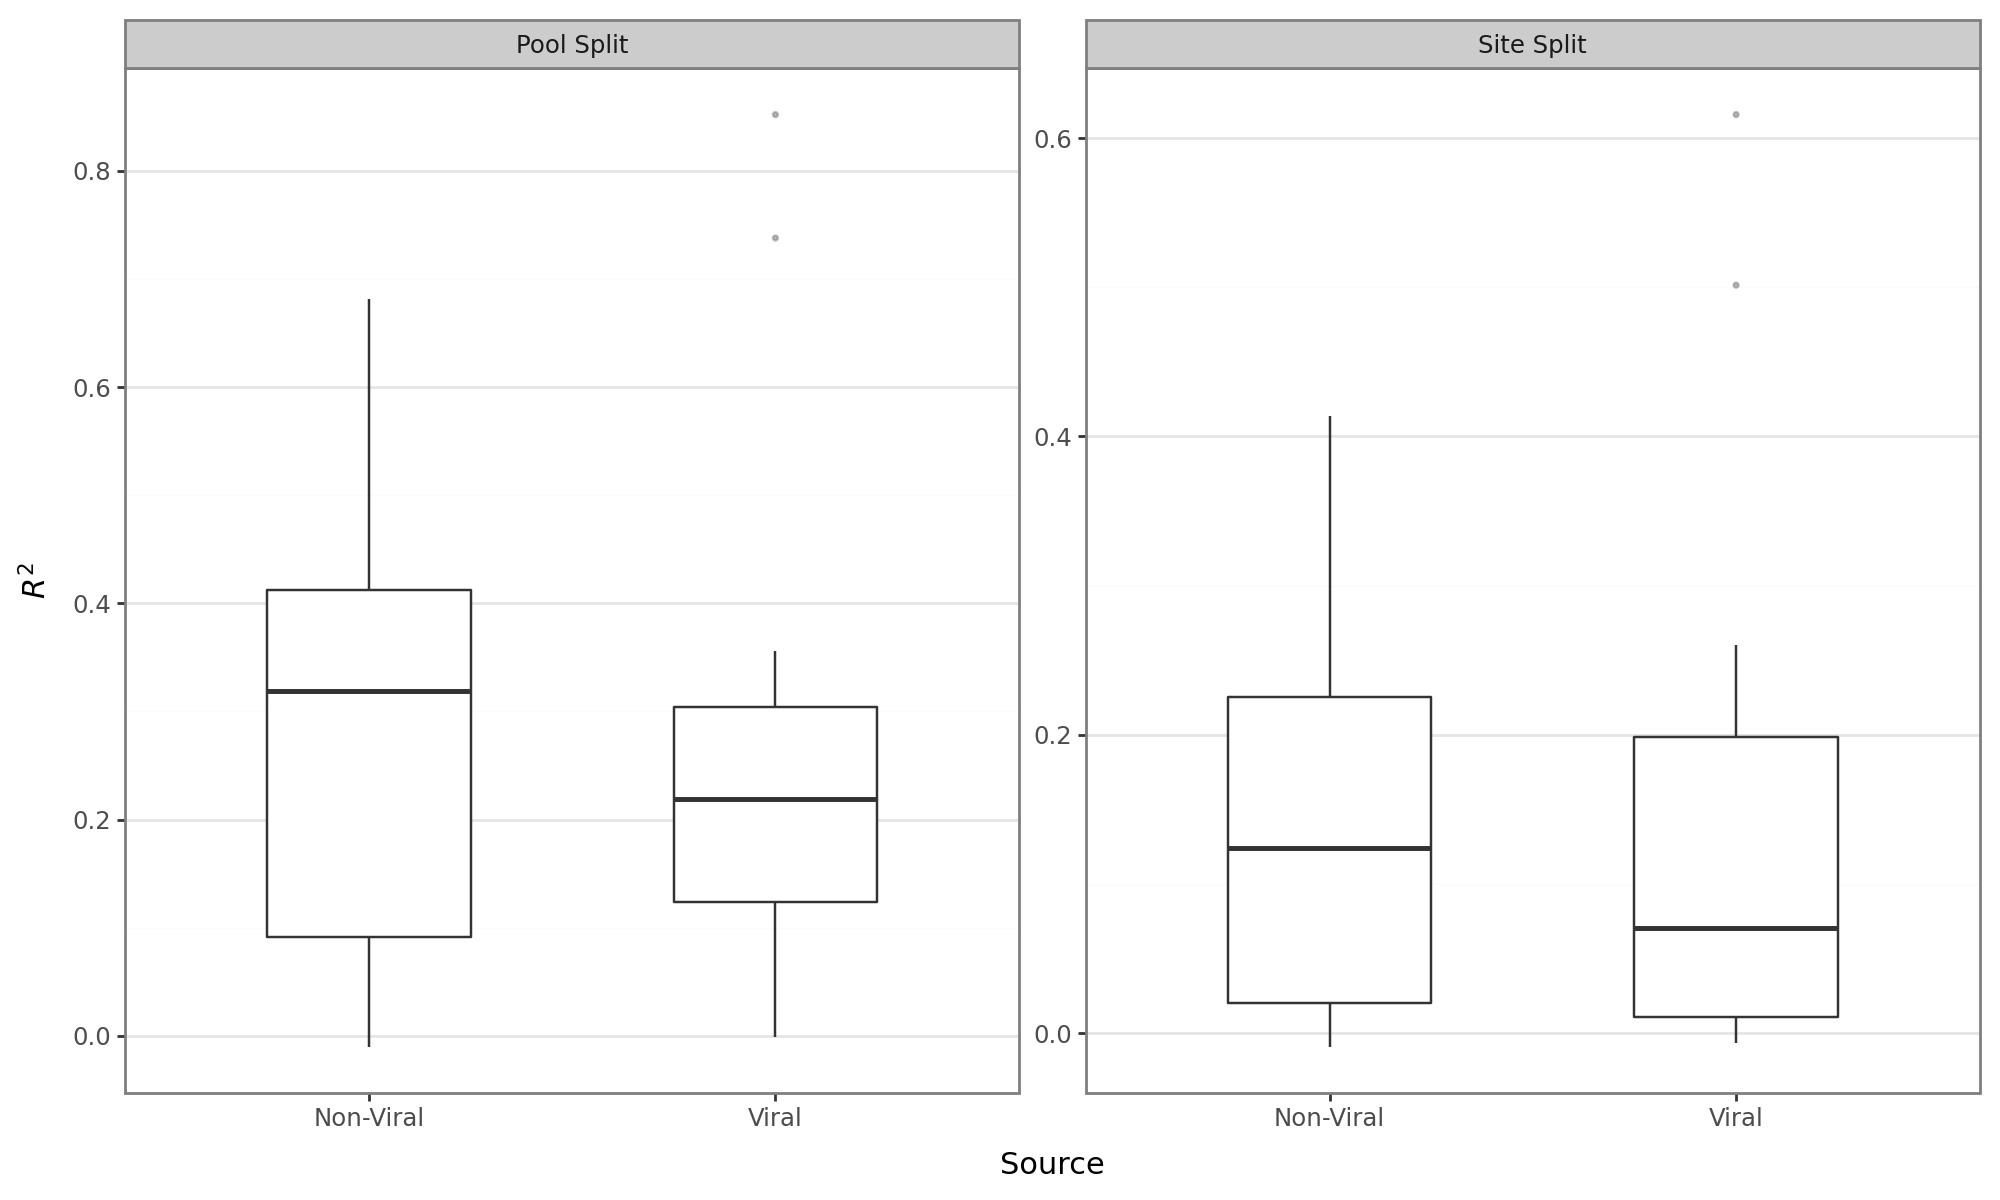

In [48]:
plot = (
    pln.ggplot(res_full.query('Model == "ESM-2 Base"'), pln.aes(x='Source', y='val_r2'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.labs(
        x='Source',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(10, 6),
        panel_grid_major_x=pln.element_blank(),
    )
    + pln.facet_wrap('split_strategy', ncol=2, scales='free_y')
)

plot

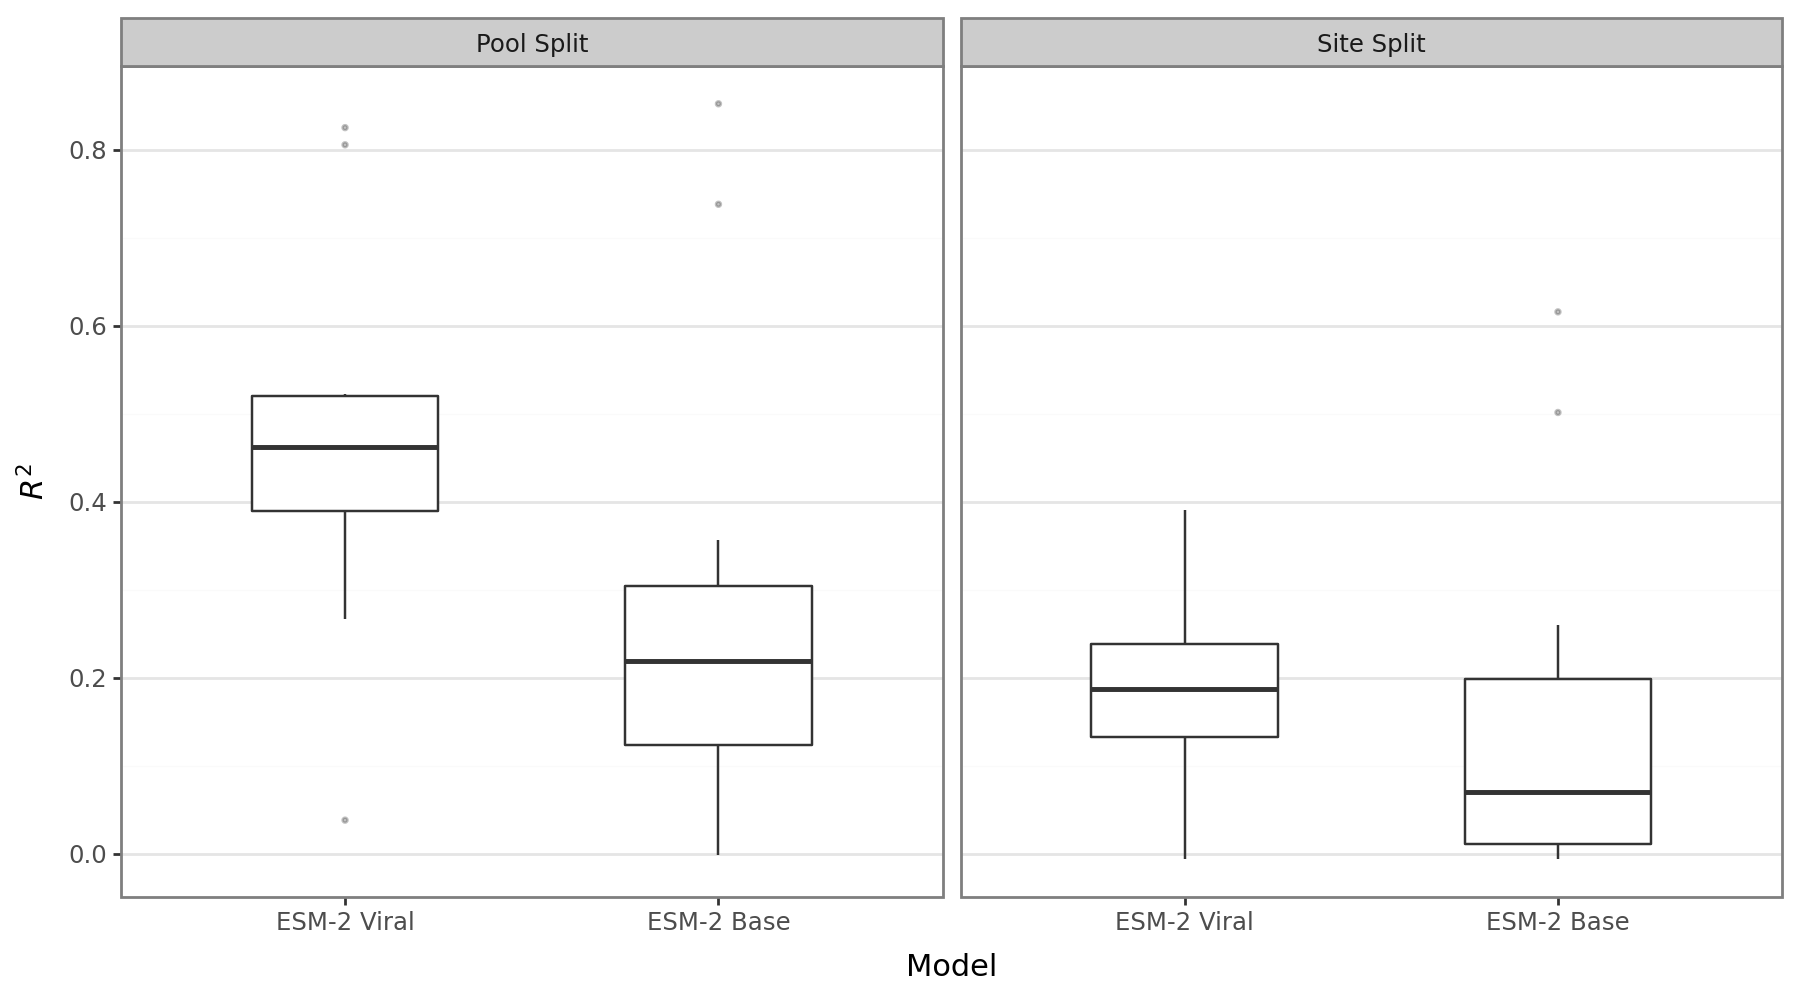

In [49]:
plot = (
    pln.ggplot(res_full.query('Source =="Viral"'), pln.aes(x='Model', y='val_r2'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(9, 5),
        panel_grid_major_x=pln.element_blank(),
    )
    #+ pln.ylim(-0.2, .8)
    + pln.facet_wrap('split_strategy', ncol=2)
)

plot#.save(filename='../experiments/fineTune/figures/esm2_650M_viral_x_esm2_650M_base_r2.png', dpi=600)

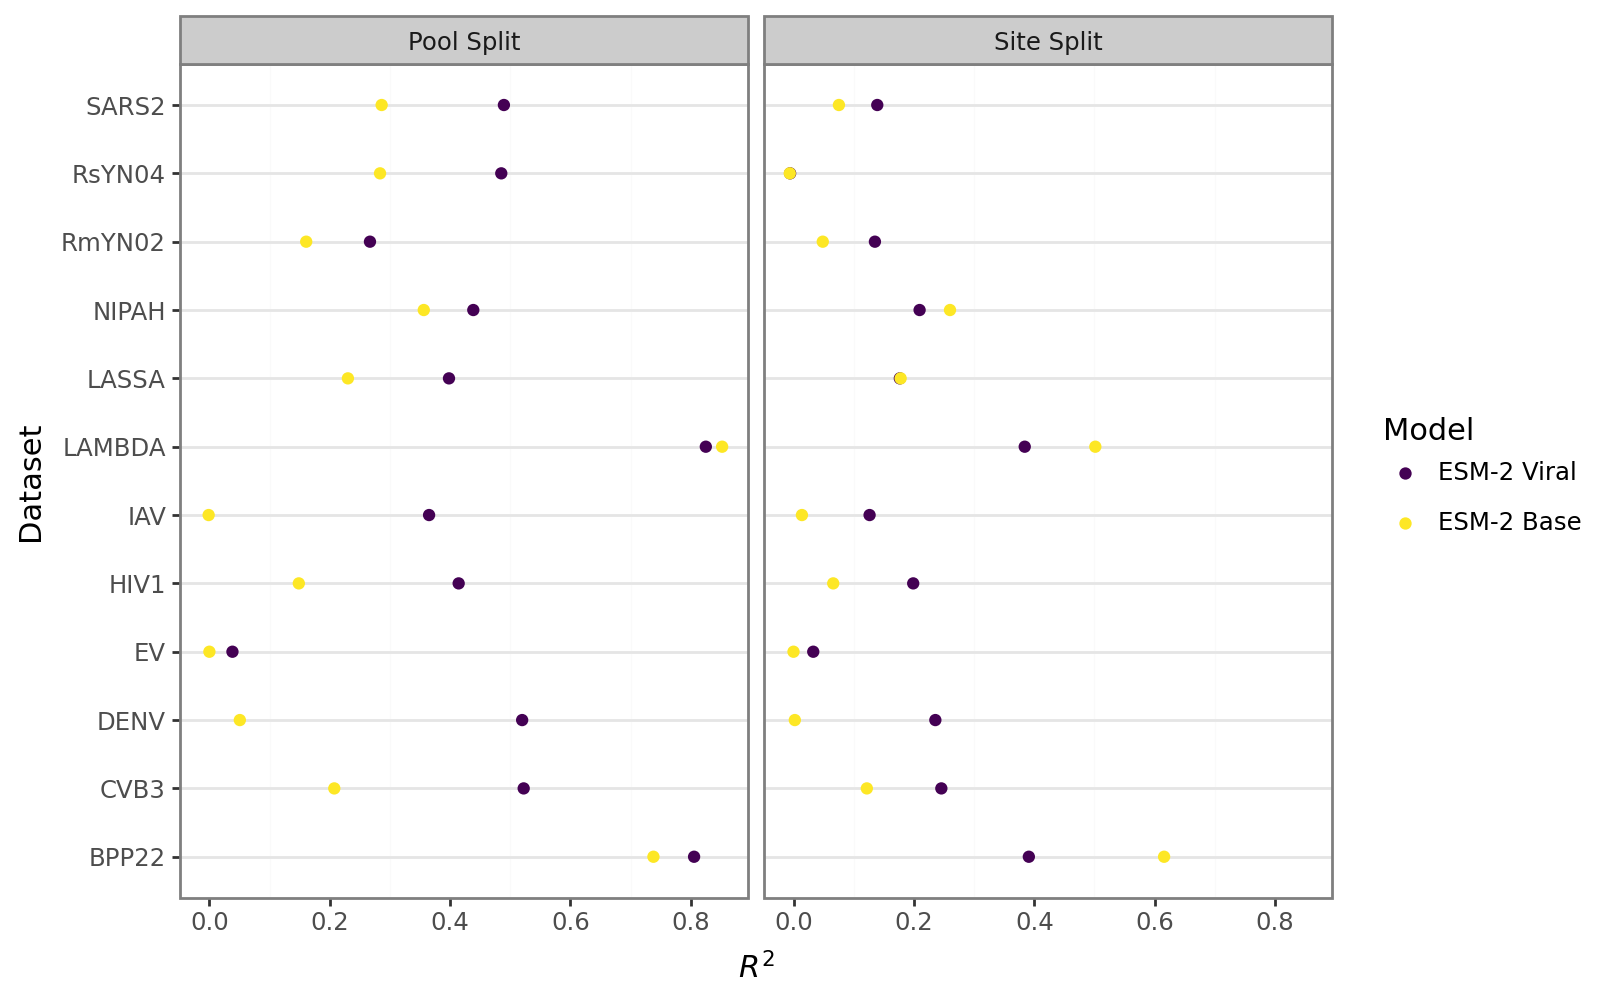

In [53]:
plot = (
    pln.ggplot(res_full.query('Source =="Viral"'), pln.aes(y='Dataset', x='val_r2', color='Model'))
    + pln.geom_point()
    + pln.labs(
        y='Dataset',
        x='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(8, 5),
        panel_grid_major_x=pln.element_blank(),
    )
    #+ pln.ylim(-0.2, .8)
    + pln.facet_wrap('split_strategy', ncol=2, )
)

plot

In [73]:
#res_full.query('Model =="ESM-2 Base"').to_csv('../experiments/fineTune/res_finetune_esm2_base.csv')
res_full.to_excel('../experiments/fineTune/res_finetune.xlsx')